In [1]:
import torch
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model, TaskType
from datasets import Dataset
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import matplotlib.pyplot as plt
import json
import os
from datetime import datetime

print("="*70)
print("MULTI-CLASS ROBERTA TRAINING")
print("="*70)

# ============= LOAD CLASS MAPPING =============
print("\n[1/6] Loading class configuration...")

try:
    with open('models/mental_health_roberta/label_mapping.json', 'r') as f:
        label_mapping = json.load(f)
    
    with open('models/mental_health_roberta/class_weights.json', 'r') as f:
        class_weights_dict = json.load(f)
    
    NUM_LABELS = len(label_mapping)
    class_weights = torch.tensor([class_weights_dict[str(i)] for i in range(NUM_LABELS)])
    
    print(f"+ Loaded configuration:")
    print(f"   Number of classes: {NUM_LABELS}")
    print(f"   Classes: {list(label_mapping.keys())}")
    
except Exception as e:
    print(f"? Error loading configuration: {e}")
    exit(1)

# ============= CONFIGURATION =============

CONFIG = {
    'model_name': 'FacebookAI/roberta-large',
    'output_dir': './models/mental_health_roberta_large_lora',
    'num_labels': NUM_LABELS,
    'num_epochs': 4,                  
    'batch_size': 2,                   
    'gradient_accumulation_steps': 8,  
    'learning_rate': 1e-5,             
    'warmup_ratio': 0.06,
    'weight_decay': 0.01,
    'max_length': 256,                 
    'early_stopping_patience': 3,
}


print("\n+ Training Configuration:")
for key, value in CONFIG.items():
    if key != 'model_name':
        print(f"  {key:<30} {value}")

# ============= DEVICE SETUP =============
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n+  Device: {device}")

if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")



MULTI-CLASS ROBERTA TRAINING

[1/6] Loading class configuration...
+ Loaded configuration:
   Number of classes: 7
   Classes: ['Normal', 'Anxiety', 'Depression', 'Stress', 'Suicidal', 'Bipolar', 'Personality disorder']

+ Training Configuration:
  output_dir                     ./models/mental_health_roberta_large_lora
  num_labels                     7
  num_epochs                     4
  batch_size                     2
  gradient_accumulation_steps    8
  learning_rate                  1e-05
  warmup_ratio                   0.06
  weight_decay                   0.01
  max_length                     256
  early_stopping_patience        3

+  Device: cuda
  GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
  Memory: 6.44 GB


In [2]:
# ============= LOAD DATA =============
print("\n[2/6] Loading datasets...")

try:
    train_df = pd.read_csv('data/train.csv')
    val_df = pd.read_csv('data/val.csv')
    
    print(f"+ Train: {len(train_df)} samples")
    print(f"+ Val:   {len(val_df)} samples")
    
    print(f"\n+ Training set class distribution:")
    for class_name, class_idx in sorted(label_mapping.items(), key=lambda x: x[1]):
        count = (train_df['label'] == class_idx).sum()
        print(f"  [{class_idx}] {class_name:<25} {count:>6} samples")
    
    train_dataset = Dataset.from_pandas(train_df)
    val_dataset = Dataset.from_pandas(val_df)
    
except Exception as e:
    print(f"? Error loading data: {e}")
    exit(1)




[2/6] Loading datasets...
+ Train: 35058 samples
+ Val:   7512 samples

+ Training set class distribution:
  [0] Normal                     10716 samples
  [1] Anxiety                     2515 samples
  [2] Depression                 10462 samples
  [3] Stress                      1602 samples
  [4] Suicidal                    7397 samples
  [5] Bipolar                     1744 samples
  [6] Personality disorder         622 samples


In [3]:
# ============= TOKENIZATION =============
print("\n[3/6] Loading tokenizer and tokenizing...")

tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        padding='max_length',
        max_length=CONFIG['max_length']
    )

print("Tokenizing datasets...")
train_dataset = train_dataset.map(tokenize_function, batched=True, remove_columns=['text'])
val_dataset = val_dataset.map(tokenize_function, batched=True, remove_columns=['text'])
print("+ Tokenization complete")




[3/6] Loading tokenizer and tokenizing...
Tokenizing datasets...


Map:   0%|          | 0/35058 [00:00<?, ? examples/s]

Map:   0%|          | 0/7512 [00:00<?, ? examples/s]

+ Tokenization complete


In [5]:
# ============= MODEL INITIALIZATION =============
print(f"\n[4/6] Loading model: {CONFIG['model_name']}")

base_model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG['model_name'],
    num_labels=CONFIG['num_labels'],
    problem_type="single_label_classification"
)

num_params = sum(p.numel() for p in model.parameters())
print(f"+ Model loaded: {num_params / 1e6:.1f}M parameters")

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,                 # can try 4–16
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["query", "value"], 
    bias="none",
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()


# ============= CUSTOM TRAINER WITH CLASS WEIGHTS =============
class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
    
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        """
        Fixed compute_loss to handle num_items_in_batch parameter
        """
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        
        if self.class_weights is not None:
            loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        else:
            loss_fct = torch.nn.CrossEntropyLoss()
        
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

# ============= METRICS =============
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    accuracy = accuracy_score(labels, predictions)
    
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, predictions, average='macro', zero_division=0
    )
    
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted', zero_division=0
    )
    
    precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(
        labels, predictions, average=None, zero_division=0
    )
    
    metrics = {
        'accuracy': accuracy,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'precision_weighted': precision_weighted,
        'recall_weighted': recall_weighted,
        'f1_weighted': f1_weighted,
    }
    
    class_names = [k for k, v in sorted(label_mapping.items(), key=lambda x: x[1])]
    for i, class_name in enumerate(class_names):
        metrics[f'f1_{class_name.lower().replace(" ", "_").replace("-", "_")}'] = f1_per_class[i]
    
    return metrics




[4/6] Loading model: FacebookAI/roberta-large


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


+ Model loaded: 355.4M parameters
trainable params: 1,843,207 || all params: 357,210,126 || trainable%: 0.5160


In [6]:
# ============= TRAINING SETUP =============
print("\n[5/6] Setting up training...")

os.makedirs(CONFIG['output_dir'], exist_ok=True)
os.makedirs('results', exist_ok=True)

training_args = TrainingArguments(
    output_dir=CONFIG['output_dir'],
    num_train_epochs=CONFIG['num_epochs'],
    per_device_train_batch_size=CONFIG['batch_size'],
    per_device_eval_batch_size=CONFIG['batch_size'] * 2,
    gradient_accumulation_steps=CONFIG['gradient_accumulation_steps'],
    learning_rate=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay'],
    warmup_ratio=CONFIG['warmup_ratio'],
    
    eval_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    
    logging_dir='./logs',
    logging_steps=50,
    logging_first_step=True,
    report_to="none",
    
    fp16=torch.cuda.is_available(),
    gradient_checkpointing=True,
    optim="adamw_torch",
    
    save_total_limit=2,
    max_grad_norm=1.0,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=CONFIG['early_stopping_patience'])],
    class_weights=class_weights
)

print("+ Using weighted loss for class imbalance")




[5/6] Setting up training...


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


+ Using weighted loss for class imbalance


In [7]:
# ============= TRAINING =============
print("\n[6/6] Starting training...")
print("="*70)
print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)

training_start = datetime.now()

try:
    train_result = trainer.train()
    training_end = datetime.now()
    training_duration = (training_end - training_start).total_seconds() / 60
    
    print("\n" + "="*70)
    print("+ TRAINING COMPLETE")
    print("="*70)
    print(f"Duration: {training_duration:.2f} minutes ({training_duration/60:.2f} hours)")
    
except KeyboardInterrupt:
    print("\n?  Training interrupted")
    training_end = datetime.now()
    training_duration = (training_end - training_start).total_seconds() / 60
except Exception as e:
    print(f"\n? Training failed: {e}")
    import traceback
    traceback.print_exc()
    exit(1)

# ============= SAVE MODEL =============
print(f"\n+ Saving model...")

trainer.save_model(CONFIG['output_dir'])
tokenizer.save_pretrained(CONFIG['output_dir'])
print("+ Model saved")

# ============= FINAL VALIDATION =============
print("\n+ Running final validation...")

val_results = trainer.evaluate()

print("\n" + "="*70)
print("FINAL VALIDATION METRICS")
print("="*70)
print(f"{'Accuracy:':<30} {val_results['eval_accuracy']:.4f}")
print(f"{'F1 (Macro):':<30} {val_results['eval_f1_macro']:.4f}")
print(f"{'F1 (Weighted):':<30} {val_results['eval_f1_weighted']:.4f}")

print("\n+ Per-Class F1 Scores:")
class_names = [k for k, v in sorted(label_mapping.items(), key=lambda x: x[1])]
for class_name in class_names:
    key = f'eval_f1_{class_name.lower().replace(" ", "_").replace("-", "_")}'
    if key in val_results:
        f1 = val_results[key]
        bar = '*' * int(f1 * 50)
        print(f"  {class_name:<25} {f1:.4f} {bar}")

# ============= SAVE RESULTS =============
training_log = {
    'model_name': CONFIG['model_name'],
    'num_labels': CONFIG['num_labels'],
    'classes': list(label_mapping.keys()),
    'training_duration_minutes': training_duration,
    'final_metrics': {
        k.replace('eval_', ''): float(v) if isinstance(v, (np.floating, float)) else v 
        for k, v in val_results.items()
    }
}

with open('results/training_log.json', 'w') as f:
    json.dump(training_log, f, indent=2)

print("\n+ Saved: results/training_log.json")




[6/6] Starting training...
Start time: 2026-02-16 23:12:28


Step,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted,F1 Normal,F1 Anxiety,F1 Depression,F1 Stress,F1 Suicidal,F1 Bipolar,F1 Personality Disorder
200,15.118190,1.890164,0.216720,0.090783,0.131646,0.093326,0.162059,0.216720,0.169937,0.000000,0.063334,0.468542,0.000000,0.121406,0.000000,0.000000
400,13.807278,1.799931,0.466720,0.189487,0.236011,0.209774,0.372317,0.466720,0.413339,0.696563,0.000000,0.430337,0.000000,0.341520,0.000000,0.000000
600,12.907748,1.673664,0.435437,0.292980,0.238377,0.175290,0.419970,0.435437,0.330848,0.707843,0.011050,0.074343,0.000000,0.433795,0.000000,0.000000
800,11.091592,1.456736,0.600373,0.494170,0.329585,0.321685,0.587501,0.600373,0.552311,0.813990,0.369565,0.600832,0.000000,0.462074,0.005333,0.000000
1000,8.860898,1.137300,0.690628,0.544897,0.522050,0.530595,0.670306,0.690628,0.678561,0.845512,0.643130,0.663530,0.377551,0.619286,0.565154,0.000000
1200,7.672565,1.021517,0.711129,0.567676,0.535663,0.547134,0.692716,0.711129,0.698021,0.864876,0.675547,0.695472,0.385417,0.620048,0.588580,0.000000
1400,7.754938,0.921637,0.730964,0.707140,0.586892,0.605695,0.730390,0.730964,0.724944,0.877005,0.694836,0.692325,0.465490,0.682232,0.642547,0.185430
1600,6.847195,0.864449,0.745873,0.721904,0.610365,0.625556,0.745176,0.745873,0.739785,0.887904,0.707811,0.707217,0.522936,0.690799,0.676796,0.185430
1800,6.288053,0.825848,0.754792,0.724667,0.641317,0.658193,0.757562,0.754792,0.751295,0.895030,0.723363,0.732109,0.559585,0.668926,0.700855,0.327485
2000,5.937257,0.789086,0.760783,0.731300,0.652221,0.662731,0.764129,0.760783,0.758348,0.898526,0.728324,0.723066,0.574497,0.704072,0.717949,0.292683


c:\Users\Parva\AppData\Local\Programs\Python\Python311\Lib\site-packages\peft\utils\other.py:1394: UserWarning: Unable to fetch remote file due to the following error [Errno 11001] getaddrinfo failed - silently ignoring the lookup for the file config.json in FacebookAI/roberta-large.
  warnings.warn(
c:\Users\Parva\AppData\Local\Programs\Python\Python311\Lib\site-packages\peft\utils\save_and_load.py:295: UserWarning: Could not find a config file in FacebookAI/roberta-large - will assume that the vocabulary was not modified.
  warnings.warn(
c:\Users\Parva\AppData\Local\Programs\Python\Python311\Lib\site-packages\peft\utils\other.py:1394: UserWarning: Unable to fetch remote file due to the following error [Errno 11001] getaddrinfo failed - silently ignoring the lookup for the file config.json in FacebookAI/roberta-large.
  warnings.warn(
c:\Users\Parva\AppData\Local\Programs\Python\Python311\Lib\site-packages\peft\utils\save_and_load.py:295: UserWarning: Could not find a config file in 


+ TRAINING COMPLETE
Duration: 318.35 minutes (5.31 hours)

+ Saving model...
+ Model saved

+ Running final validation...


c:\Users\Parva\AppData\Local\Programs\Python\Python311\Lib\site-packages\peft\utils\save_and_load.py:295: UserWarning: Could not find a config file in FacebookAI/roberta-large - will assume that the vocabulary was not modified.
  warnings.warn(



FINAL VALIDATION METRICS
Accuracy:                      0.8075
F1 (Macro):                    0.7695
F1 (Weighted):                 0.8076

+ Per-Class F1 Scores:
  Normal                    0.9266 **********************************************
  Anxiety                   0.8168 ****************************************
  Depression                0.7622 **************************************
  Stress                    0.6863 **********************************
  Suicidal                  0.7345 ************************************
  Bipolar                   0.8164 ****************************************
  Personality disorder      0.6439 ********************************

+ Saved: results/training_log.json


+ Saved: results/training_curves.png


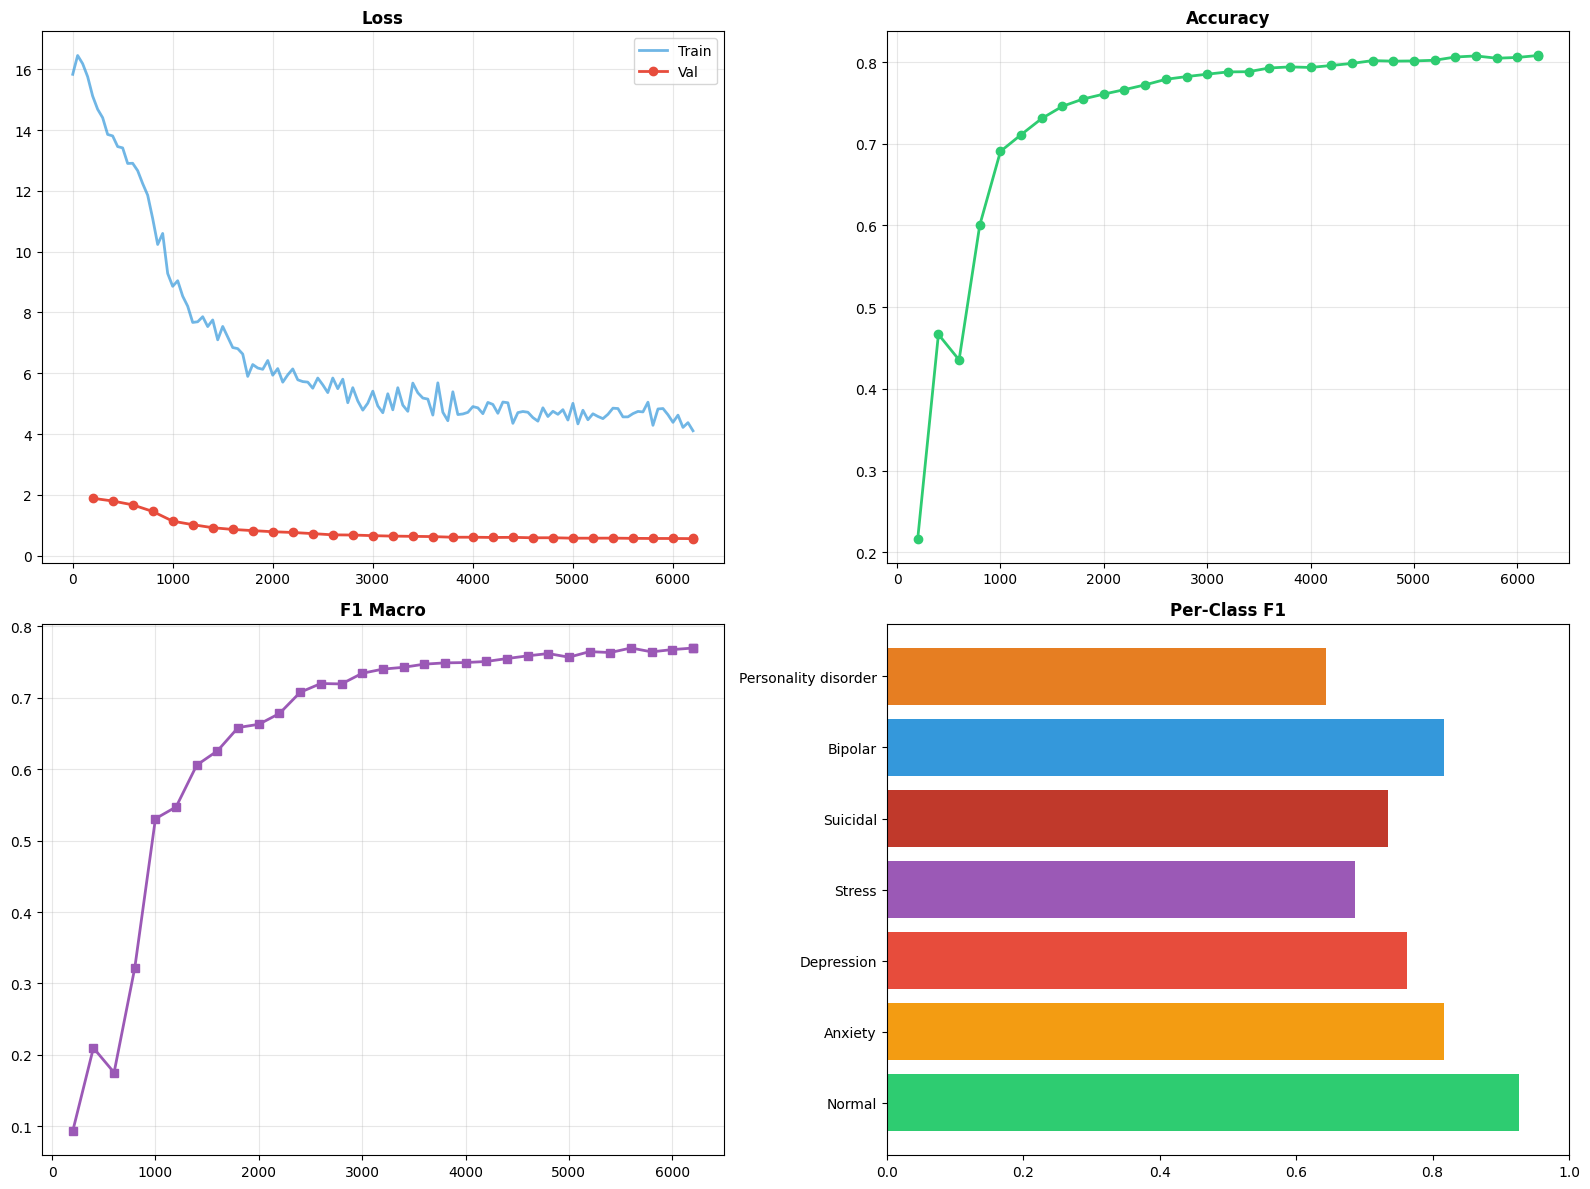

In [8]:
# ============= TRAINING CURVES =============
log_history = trainer.state.log_history

train_loss = [x['loss'] for x in log_history if 'loss' in x]
train_steps = [x['step'] for x in log_history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in log_history if 'eval_loss' in x]
eval_acc = [x['eval_accuracy'] for x in log_history if 'eval_accuracy' in x]
eval_f1_macro = [x['eval_f1_macro'] for x in log_history if 'eval_f1_macro' in x]
eval_steps = [x['step'] for x in log_history if 'eval_loss' in x]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(train_steps, train_loss, label='Train', linewidth=2, color='#3498db', alpha=0.7)
axes[0, 0].plot(eval_steps, eval_loss, label='Val', linewidth=2, color='#e74c3c', marker='o')
axes[0, 0].set_title('Loss', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(eval_steps, eval_acc, linewidth=2, color='#2ecc71', marker='o')
axes[0, 1].set_title('Accuracy', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(eval_steps, eval_f1_macro, linewidth=2, color='#9b59b6', marker='s')
axes[1, 0].set_title('F1 Macro', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

class_f1 = [val_results.get(f'eval_f1_{c.lower().replace(" ","_").replace("-","_")}', 0) for c in class_names]
axes[1, 1].barh(class_names, class_f1, color=['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', '#c0392b', '#3498db', '#e67e22'])
axes[1, 1].set_title('Per-Class F1', fontweight='bold')
axes[1, 1].set_xlim([0, 1])

plt.tight_layout()
plt.savefig('results/training_curves.png', dpi=300, bbox_inches='tight')
print("+ Saved: results/training_curves.png")
